In [15]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import pickle
import os


def load_data(path='data.parquet'):
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    df = df.ffill()
    return df

# load the data
df = load_data()

In [16]:
# calculate spread and pnl
df['spread'] = df['banknifty'] - df['nifty']
df['pnl'] = df['spread'] * (df['tte'] ** 0.7)


Grid search for Finding Optimal parameter


In [17]:
def grid_search(df):
    entry_z_list = np.arange(1.5, 3.1, 0.2)
    exit_z_list = np.arange(0, 1.1, 0.2)
    window_list = [30, 60, 90, 120, 150]
    results = []

    for window in tqdm(window_list, desc="Window"):
        spread_mean = df['spread'].rolling(window).mean()
        spread_std = df['spread'].rolling(window).std()
        zscore = (df['spread'] - spread_mean) / spread_std

        for entry_z in entry_z_list:
            for exit_z in exit_z_list:
                position = 0
                positions = np.zeros(len(df))
                for i in range(window, len(df)):
                    if position == 0:
                        if zscore.iloc[i] > entry_z:
                            position = -1
                        elif zscore.iloc[i] < -entry_z:
                            position = 1
                    elif position == 1 and zscore.iloc[i] >= exit_z:
                        position = 0
                    elif position == -1 and zscore.iloc[i] <= -exit_z:
                        position = 0
                    positions[i] = position

                strategy_pnl = np.roll(positions, 1) * df['pnl'].values
                strategy_pnl[0] = 0
                cum_strategy_pnl = np.cumsum(strategy_pnl)
                temp_df = df.copy()
                temp_df['strategy_pnl'] = strategy_pnl
                daily_pnl = temp_df['strategy_pnl'].resample('D').sum()
                daily_pnl = daily_pnl[daily_pnl != 0]
                sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
                abs_return = cum_strategy_pnl[-1]
                rolling_max = np.maximum.accumulate(cum_strategy_pnl)
                drawdown = cum_strategy_pnl - rolling_max
                max_drawdown = drawdown.min()
                results.append({
                    'window': window,
                    'entry_z': entry_z,
                    'exit_z': exit_z,
                    'abs_return': abs_return,
                    'sharpe': sharpe,
                    'max_drawdown': max_drawdown
                })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='sharpe', ascending=False)
    return results_df
# Cache results to avoid recomputation
cache_path = 'grid_search_results.pkl'
if os.path.exists(cache_path) and os.path.getsize(cache_path) > 0:
    with open(cache_path, 'rb') as f:
        results_df = pickle.load(f)
    print("Loaded grid search results from cache.")
else:
    results_df = grid_search(df)
    with open(cache_path, 'wb') as f:
        pickle.dump(results_df, f)
    print("Computed and cached grid search results.")

results_df.head(10)

Loaded grid search results from cache.


,window,entry_z,exit_z,abs_return,sharpe,max_drawdown
152,120,1.7,0.4,57293.900183,5.022105,-6770.115337
205,150,1.9,0.2,46397.275957,4.986738,-5389.020593
158,120,1.9,0.4,55684.044386,4.955377,-6720.021548
151,120,1.7,0.2,48512.048272,4.900660,-5456.149423
211,150,2.1,0.2,45123.382515,4.890425,-5427.970613
154,120,1.7,0.8,61734.265192,4.818429,-7681.280262
106,90,1.7,0.8,62645.531562,4.760684,-8365.954470
157,120,1.9,0.2,46152.315484,4.737980,-5369.590291
118,90,2.1,0.8,59516.582718,4.716313,-7628.331756
217,150,2.3,0.2,41905.163371,4.670124,-5476.813905


In [18]:
optimal = results_df.iloc[0]
window = int(optimal['window']) # 90
entry_z = optimal['entry_z'] # 1.5
exit_z = optimal['exit_z'] # 0.8

# Calculate rolling mean and std for spread
df['spread_mean'] = df['spread'].rolling(window).mean()
df['spread_std'] = df['spread'].rolling(window).std()
df['zscore'] = (df['spread'] - df['spread_mean']) / df['spread_std']

# Initialize position and PnL columns
df['position'] = 0  # 1 for long, -1 for short, 0 for flat

# Generate signals
position = 0
for i in range(window, len(df)):
    if position == 0:
        if df['zscore'].iloc[i] > entry_z:
            position = -1  # Short spread
        elif df['zscore'].iloc[i] < -entry_z:
            position = 1   # Long spread
    elif position == 1 and df['zscore'].iloc[i] >= exit_z:
        position = 0
    elif position == -1 and df['zscore'].iloc[i] <= -exit_z:
        position = 0
    df.at[df.index[i], 'position'] = position

# Calculate strategy PnL 
df['strategy_pnl'] = df['position'].shift().fillna(0) * df['pnl']
df['cum_pnl'] = df['strategy_pnl'].cumsum()
df[['spread', 'zscore', 'position', 'strategy_pnl', 'cum_pnl']].tail()

,spread,zscore,position,strategy_pnl,cum_pnl
time,,,,,
2022-06-30 15:26:00,0.025943,0.389088,0,0.0,57293.900183
2022-06-30 15:27:00,0.024317,-0.891080,0,0.0,57293.900183
2022-06-30 15:28:00,0.025321,-0.123756,0,0.0,57293.900183
2022-06-30 15:29:00,0.026971,1.190425,0,0.0,57293.900183
2022-06-30 15:30:00,0.025827,0.240944,0,0.0,57293.900183


In [19]:
def calculate_trade_duration(df):
    # Get position changes and their timestamps
    position_changes = df['position'].diff().fillna(0)
    
    # Create trading hours mask
    trading_mask = (df.index.hour >= 9) & (df.index.hour <= 15)
    trading_mask &= ~((df.index.hour == 9) & (df.index.minute < 15))
    trading_mask &= ~((df.index.hour == 15) & (df.index.minute > 30))
    
    # Combine position changes with trading mask
    valid_changes = (position_changes != 0) & trading_mask
    trade_points = df.index[valid_changes]
    
    # Calculate durations
    durations = []
    for i in range(len(trade_points)-1):
        start_time = trade_points[i]
        end_time = trade_points[i+1]
        
        # Convert to minutes considering only trading hours
        duration_minutes = 0
        current_time = start_time
        
        while current_time < end_time:
            next_time = min(
                current_time + pd.Timedelta(minutes=1),
                end_time
            )
            
            # Check if current minute is in trading hours
            if (9 <= current_time.hour <= 15 and
                not (current_time.hour == 9 and current_time.minute < 15) and
                not (current_time.hour == 15 and current_time.minute > 30)):
                duration_minutes += 1
                
            current_time = next_time
            
        durations.append(duration_minutes / 60)  # Convert to hours
    
    avg_duration = np.mean(durations) if durations else 0
    return avg_duration

In [ ]:
# Calculate performance metrics
absolute_return = df['cum_pnl'].iloc[-1]

# Sharpe Ratio
daily_pnl = df['strategy_pnl'].resample('D').sum()
daily_pnl = daily_pnl[daily_pnl != 0]
sharpe_ratio = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0

# Max Drawdown and Max Drawdown %
cum_pnl = df['cum_pnl'].fillna(0)
rolling_max = cum_pnl.cummax()
drawdown = cum_pnl - rolling_max
max_drawdown = drawdown.min()
max_drawdown_pct = (max_drawdown / rolling_max.max()) * 100 if rolling_max.max() != 0 else np.nan

# Win Rate
trade_pnls = df['strategy_pnl'][df['strategy_pnl'] != 0]
wins = (trade_pnls > 0).sum()
losses = (trade_pnls < 0).sum()
win_rate = wins / (wins + losses) if (wins + losses) > 0 else np.nan

# Trade Count
trade_count = (df['position'].diff().abs() > 0).sum()
avg_duration = calculate_trade_duration(df)

print(f"Avg. Trade Duration (hours): {avg_duration:.2f}")
print(f"Absolute Return: {absolute_return:.2f}")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}")
print(f"Max Drawdown %: {max_drawdown_pct:.2f}%")
print(f"Win Rate: {win_rate:.2%}")
print(f"Trade Count: {trade_count}")

Avg. Trade Duration (in Hours): 0.71
Absolute Return: 57293.90
Annualized Sharpe Ratio: 5.02
Max Drawdown: -6770.12
Max Drawdown %: -11.19%
Win Rate: 65.26%
Trade Count: 4858


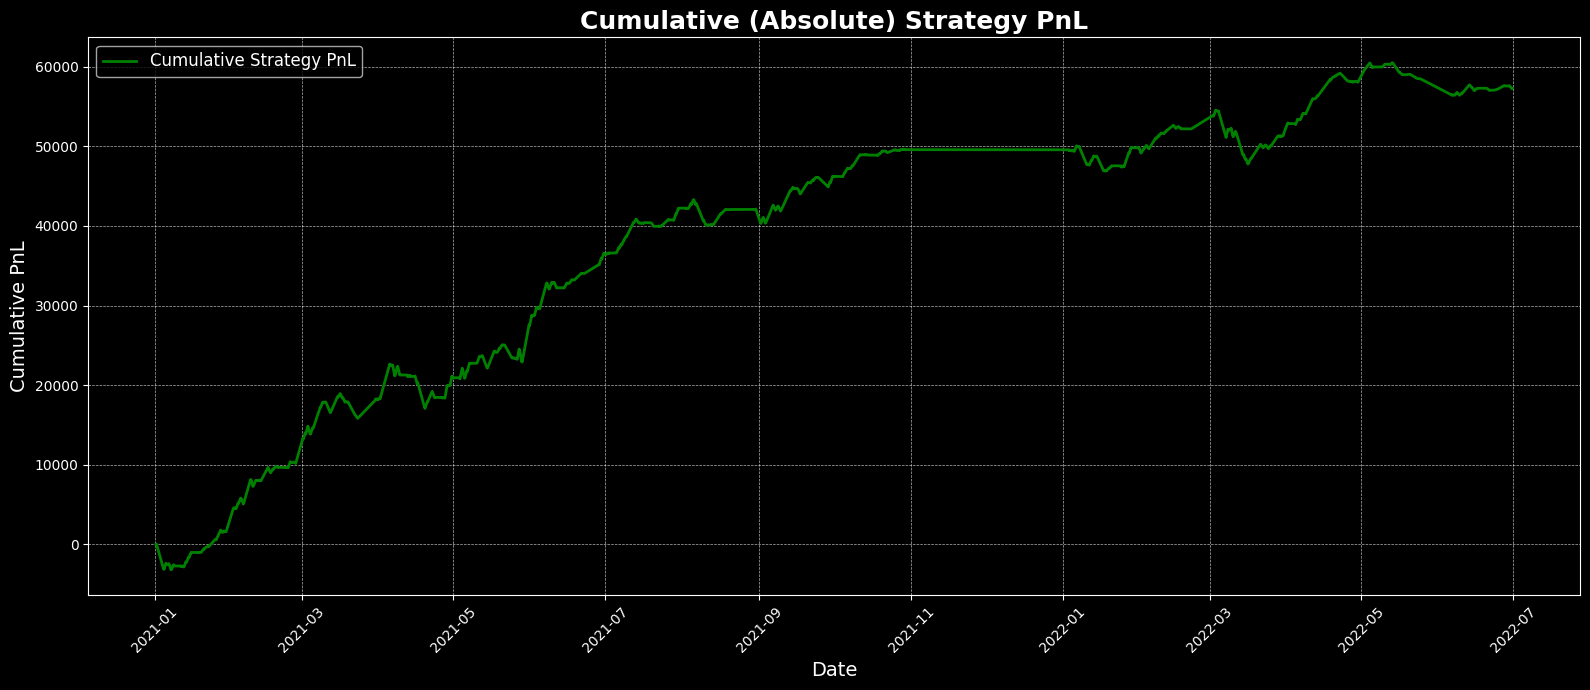

In [21]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df.index, df['cum_pnl'], label='Cumulative Strategy PnL', color='green', linewidth=2)
ax.set_title('Cumulative (Absolute) Strategy PnL', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Cumulative PnL', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()